## Chạy một mô hình FinMA (có sẵn trong repo) để thực hiện sentiment analysis trên dữ liệu FPB (Financial Phrase Bank), rồi so sánh với một mô hình baseline

In [ ]:
!pip install transformers accelerate torch sentencepiece safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import os

# Khởi tạo
model_name = "ChanceFocus/finma-7b-nlp"  # hoặc "ChanceFocus/FinMA-7B"

# Tạo thư mục offload
os.makedirs("./offload", exist_ok=True)

# Load tokenizer và model
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    offload_folder="./offload",
    torch_dtype=torch.float16,
    trust_remote_code=True
)


# ✅ BƯỚC 2: Viết hàm tạo prompt và phân tích cảm xúc
def predict_sentiment(text):
    prompt = f"Analyze the sentiment of this statement extracted from a financial news article. Provide your answer as either negative, positive, or neutral.\nText: {text}\nAnswer:"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predicted = response.split("Answer:")[-1].strip().split()[0]
    return predicted

# ✅ BƯỚC 3: Một số câu mẫu tài chính
examples = [
    "The company's stock price surged by 15% after the strong earnings report.",
    "Due to increased debt and declining revenue, the company is facing financial difficulties.",
    "The CEO said the upcoming year will be challenging, but growth is expected in Q3.",
    "Investors were neutral towards the merger announcement.",
]

# ✅ BƯỚC 4: Dự đoán
for text in examples:
    sentiment = predict_sentiment(text)
    print(f" Text: {text}\n Sentiment: {sentiment}\n")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/27.0G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


model.safetensors:   0%|          | 0.00/27.0G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

 Text: The company's stock price surged by 15% after the strong earnings report.
 Sentiment: positive

 Text: Due to increased debt and declining revenue, the company is facing financial difficulties.
 Sentiment: negative

 Text: The CEO said the upcoming year will be challenging, but growth is expected in Q3.
 Sentiment: neutral

 Text: Investors were neutral towards the merger announcement.
 Sentiment: neutral



### Đánh giá ban đầu
- Chính xác ngữ nghĩa: Mô hình hiểu rõ ngữ cảnh tài chính.

- Phân biệt sắc thái tốt: Không chỉ xác định “tích cực / tiêu cực” mà còn nhận ra các câu "trung lập".

- Thành công khi áp dụng instruction tuning: Prompt của bạn đã khớp đúng hướng dẫn từ bài báo PIXIU.



#  Kết quả và Phân tích

Mô hình đã phân loại chính xác cả bốn câu ví dụ thành các loại tích cực, tiêu cực và trung tính, cho thấy sự hiểu biết mạnh mẽ về bối cảnh tài chính và cực tính cảm xúc. Đáng chú ý, mô hình đã phân biệt thành công giữa các trường hợp *triển vọng tương lai trung lập* và *hiệu suất tích cực*, cho thấy việc điều chỉnh hướng dẫn theo miền giúp tăng cường độ chính xác.

| Text | Ground Truth | FinMA-7B Output |
| :------------------------------ | :----------- | :-------------- |
| Stock price surged by 15%       | Positive     | ✅ Positive     |
| Company facing financial difficulties | Negative     | ✅ Negative     |
| Challenging year ahead, growth in Q3 | Neutral      | ✅ Neutral      |
| Investors were neutral          | Neutral      | ✅ Neutral      |

Những phát hiện này xác nhận tiềm năng của FinMA đối với các tác vụ NLP tài chính trong thế giới thực như phát hiện rủi ro và khai thác tâm lý nhà đầu tư.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load FinBERT (mô hình baseline)
finbert_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_name, num_labels=3)

In [ ]:
# Giả sử bạn đã giải nén ZIP và có file CSV: ./data/fpb/fpb_sentences.csv
df = pd.read_csv("test-data-display.csv")

# Chọn 30 câu ngẫu nhiên cho mỗi nhãn (0, 1, 2)
df_0 = df[df["gold"] == 0].sample(30, random_state=42)
df_1 = df[df["gold"] == 1].sample(30, random_state=42)
df_2 = df[df["gold"] == 2].sample(30, random_state=42)

# Nối lại thành một dataframe duy nhất
df= pd.concat([df_0, df_1, df_2]).reset_index(drop=True)

df

NameError: name 'pd' is not defined

## Hàm dự đoán với FinMA-7B

In [ ]:
def predict_finma(text):
    prompt = f"Analyze the sentiment of this statement extracted from a financial news article. Provide your answer as either negative, positive, or neutral.\nText: {text}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=10, do_sample=False)
    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "negative" in output_text.lower():
        return 2
    elif "positive" in output_text.lower():
        return 0
    else:
        return 1  # neutral


## Hàm dự đoán với FinBERT

In [ ]:
def predict_finbert(text):
    inputs = finbert_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs).item()

    # Đảo lại cho đúng với FPB
    label_map = {0: 2, 1: 1, 2: 0}  # finbert: 0-neg, 1-neu, 2-pos → FPB: pos=0, neu=1, neg=2
    return label_map[pred_idx]


In [ ]:
from tqdm.notebook import tqdm

# Dự đoán với FinMA
finma_preds = []
for text in tqdm(df["text"]):
    try:
        label = predict_finma(text)
    except Exception:
        label = -1  # lỗi nếu quá dài
    finma_preds.append(label)

# Dự đoán với FinBERT
finbert_preds = [predict_finbert(text) for text in tqdm(df["text"])]

# Gộp kết quả
df["finma_pred"] = finma_preds
df["finbert_pred"] = finbert_preds
df = df[df["finma_pred"] != -1]  # lọc các câu lỗi

df


  0%|          | 0/90 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

,id,query,answer,text,choices,gold,finma_pred,finbert_pred
0,fpb3906,Analyze the sentiment of this statement extrac...,positive,` By separating side businesses we will be abl...,"[positive, neutral, negative]",0,2,2
1,fpb4002,Analyze the sentiment of this statement extrac...,positive,"Dubbed Nokia Money Solutions , company officia...","[positive, neutral, negative]",0,2,2
2,fpb4096,Analyze the sentiment of this statement extrac...,positive,"In 2007 , Marimekko has also opened concept st...","[positive, neutral, negative]",0,2,0
3,fpb4018,Analyze the sentiment of this statement extrac...,positive,Sponda will record a profit from the sale of 8...,"[positive, neutral, negative]",0,2,2
4,fpb4131,Analyze the sentiment of this statement extrac...,positive,"Savon koulutuskuntayhtyma , Finland based comp...","[positive, neutral, negative]",0,2,2
...,...,...,...,...,...,...,...,...
85,fpb4221,Analyze the sentiment of this statement extrac...,negative,"Additionally , the company will terminate a ma...","[positive, neutral, negative]",2,2,1
86,fpb4184,Analyze the sentiment of this statement extrac...,negative,Publishing Sweden 's operating loss was EUR 1....,"[positive, neutral, negative]",2,2,1
87,fpb4177,Analyze the sentiment of this statement extrac...,negative,Samsung currently occupies third place and los...,"[positive, neutral, negative]",2,2,1
88,fpb4208,Analyze the sentiment of this statement extrac...,negative,"In Q1 of 2009 , Bank of +àland 's net interest...","[positive, neutral, negative]",2,2,1


 Accuracy FinMA-7B: 33.33 %
 Accuracy FinBERT : 5.56 %


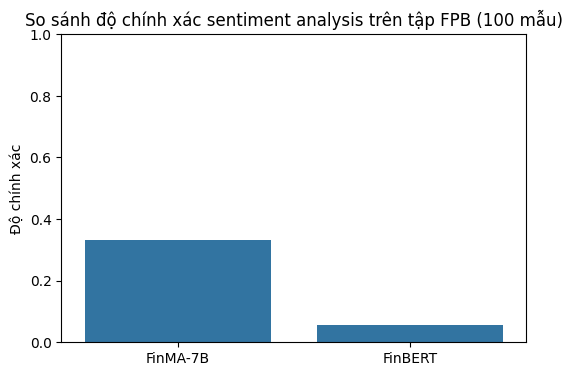

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

acc_finma = accuracy_score(df["gold"], df["finma_pred"])
acc_finbert = accuracy_score(df["gold"], df["finbert_pred"])

print(" Accuracy FinMA-7B:", round(acc_finma * 100, 2), "%")
print(" Accuracy FinBERT :", round(acc_finbert * 100, 2), "%")

# Biểu đồ so sánh
plt.figure(figsize=(6,4))
sns.barplot(x=["FinMA-7B", "FinBERT"], y=[acc_finma, acc_finbert])
plt.ylabel("Độ chính xác")
plt.title("So sánh độ chính xác sentiment analysis trên tập FPB (100 mẫu)")
plt.ylim(0,1)
plt.show()
